# AAPL Stock Price Prediction — Part 3: Models

This notebook tests two formulations of the stock prediction problem:

1. **Regression** — predict the next day's % change (`delta_pct = Close[t+1]/Close[t] - 1`)
2. **Classification** — predict the direction (up / down)

Both use XGBoost with GridSearchCV and a chronological 90/10 train–holdout split.

**Expected result:** R² ≈ 0 for regression, accuracy ≈ 50% for classification.  
This is the intended finding — it confirms the random-walk nature of daily returns shown in the EDA notebook.

**Input:** `AAPL.csv` (produced by notebook 01)

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.dummy import DummyClassifier, DummyRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------------------------------------------
# 1. Load data and build features
# ---------------------------------------------------------------
data = pd.read_csv("AAPL.csv", parse_dates=["Date"], index_col="Date")

FEATURES = [
    "RSI_14", "Stoch_%K", "Stoch_%D", "EMA_20",
    "MACD_Line", "MACD_Signal", "MACD_Diff", "Williams_%R"
]

# Close_prev: yesterday's close as a feature (no lookahead)
data["Close_prev"] = data["Close"].shift(1)
FEATURES.append("Close_prev")

# Target: next-day percentage change
data["delta_pct"] = data["Close"].pct_change().shift(-1) * 100

# Binary direction target
data["direction"] = (data["delta_pct"] >= 0).astype(int)  # 1=up, 0=down

model_df = data[FEATURES + ["delta_pct", "direction"]].dropna()

print(f"Dataset: {len(model_df)} rows  |  {model_df.index[0].date()} – {model_df.index[-1].date()}")
print(f"Class balance: {model_df['direction'].mean()*100:.1f}% up days")

Dataset: 11365 rows  |  1981-01-30 – 2026-03-05
Class balance: 53.2% up days


In [2]:
# ---------------------------------------------------------------
# 2. Chronological train / holdout split (90% / 10%)
# ---------------------------------------------------------------
SPLIT = int(len(model_df) * 0.9)

X       = model_df[FEATURES].values
y_reg   = model_df["delta_pct"].values
y_cls   = model_df["direction"].values

X_train,   X_hold   = X[:SPLIT],     X[SPLIT:]
yr_train,  yr_hold  = y_reg[:SPLIT], y_reg[SPLIT:]
yc_train,  yc_hold  = y_cls[:SPLIT], y_cls[SPLIT:]
dates_hold = model_df.index[SPLIT:]

print(f"Train: {SPLIT} rows  |  Holdout: {len(X_hold)} rows")
print(f"Holdout period: {dates_hold[0].date()} – {dates_hold[-1].date()}")

Train: 10228 rows  |  Holdout: 1137 rows
Holdout period: 2021-08-24 – 2026-03-05


In [3]:
# ---------------------------------------------------------------
# 3. Regression: predict next-day % change
# ---------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

xgb_reg = XGBRegressor(objective="reg:squarederror", n_jobs=-1, random_state=42)
param_grid_reg = {
    "n_estimators":      [100, 300],
    "max_depth":         [3, 5],
    "learning_rate":     [0.01, 0.1],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
}

grid_reg = GridSearchCV(xgb_reg, param_grid_reg, cv=tscv,
                        scoring="r2", verbose=0, n_jobs=-1)
grid_reg.fit(X_train, yr_train)
best_reg = grid_reg.best_estimator_

yr_pred_train = best_reg.predict(X_train)
yr_pred_hold  = best_reg.predict(X_hold)

r2_train  = r2_score(yr_train, yr_pred_train)
r2_hold   = r2_score(yr_hold,  yr_pred_hold)
rmse_hold = np.sqrt(mean_squared_error(yr_hold, yr_pred_hold))

# Dummy baseline (predicts mean)
dummy_r2 = r2_score(yr_hold, DummyRegressor().fit(yr_train.reshape(-1,1), yr_train).predict(X_hold))

print("=== Regression: predict delta_pct ===")
print(f"  Best params:      {grid_reg.best_params_}")
print(f"  Train R²:         {r2_train:.4f}  (high = overfitting)")
print(f"  Holdout R²:       {r2_hold:.4f}   <- key metric")
print(f"  Holdout RMSE:     {rmse_hold:.4f}%")
print(f"  Dummy baseline R²:{dummy_r2:.4f}")
print()
print("  Interpretation: R² ≈ 0 means the model has no predictive power.")
print("  The signal-to-noise ratio of daily returns is essentially zero.")

=== Regression: predict delta_pct ===
  Best params:      {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  Train R²:         0.0125  (high = overfitting)
  Holdout R²:       0.0063   <- key metric
  Holdout RMSE:     1.7627%
  Dummy baseline R²:-0.0007

  Interpretation: R² ≈ 0 means the model has no predictive power.
  The signal-to-noise ratio of daily returns is essentially zero.


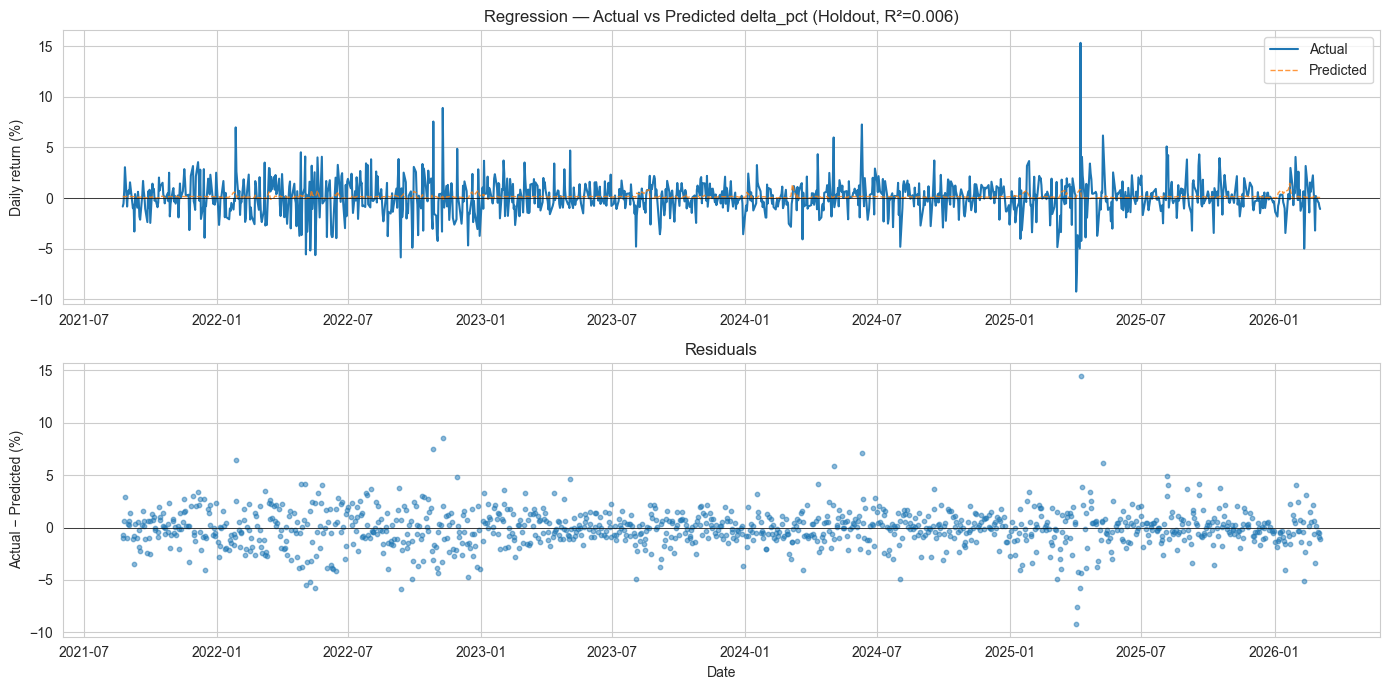

In [4]:
# ---------------------------------------------------------------
# 4. Regression — visualise holdout
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(dates_hold, yr_hold,      label="Actual",    linewidth=1.5)
axes[0].plot(dates_hold, yr_pred_hold, label="Predicted", linewidth=1, alpha=0.8, linestyle="--")
axes[0].axhline(0, color="k", linewidth=0.5)
axes[0].set_title(f"Regression — Actual vs Predicted delta_pct (Holdout, R²={r2_hold:.3f})")
axes[0].set_ylabel("Daily return (%)")
axes[0].legend()

residuals = yr_hold - yr_pred_hold
axes[1].scatter(dates_hold, residuals, alpha=0.5, s=10)
axes[1].axhline(0, color="k", linewidth=0.5)
axes[1].set_title("Residuals")
axes[1].set_ylabel("Actual − Predicted (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("plot6_regression_holdout.png", dpi=150)
plt.show()

In [5]:
# ---------------------------------------------------------------
# 5. Classification: predict direction (up / down)
# ---------------------------------------------------------------
xgb_cls = XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                         use_label_encoder=False, n_jobs=-1, random_state=42)
param_grid_cls = {
    "n_estimators":      [100, 300],
    "max_depth":         [3, 5],
    "learning_rate":     [0.01, 0.1],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
}

grid_cls = GridSearchCV(xgb_cls, param_grid_cls, cv=tscv,
                        scoring="accuracy", verbose=0, n_jobs=-1)
grid_cls.fit(X_train, yc_train)
best_cls = grid_cls.best_estimator_

yc_pred_train = best_cls.predict(X_train)
yc_pred_hold  = best_cls.predict(X_hold)

acc_train  = accuracy_score(yc_train, yc_pred_train)
acc_hold   = accuracy_score(yc_hold,  yc_pred_hold)
dummy_acc  = accuracy_score(yc_hold,
    DummyClassifier(strategy="most_frequent").fit(X_train, yc_train).predict(X_hold))

print("=== Classification: predict direction (up/down) ===")
print(f"  Best params:          {grid_cls.best_params_}")
print(f"  Train accuracy:       {acc_train:.3f}  (high = overfitting)")
print(f"  Holdout accuracy:     {acc_hold:.3f}   <- key metric")
print(f"  Dummy baseline acc:   {dummy_acc:.3f}  (always predict majority class)")
print()
print(classification_report(yc_hold, yc_pred_hold, target_names=["down","up"]))
print()
print("  Interpretation: holdout accuracy ≈ dummy baseline -> model adds no value.")

c:\Users\szymo\anaconda3\envs\geo\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Classification: predict direction (up/down) ===
  Best params:          {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
  Train accuracy:       0.538  (high = overfitting)
  Holdout accuracy:     0.533   <- key metric
  Dummy baseline acc:   0.530  (always predict majority class)

              precision    recall  f1-score   support

        down       0.51      0.12      0.20       534
          up       0.54      0.90      0.67       603

    accuracy                           0.53      1137
   macro avg       0.52      0.51      0.43      1137
weighted avg       0.52      0.53      0.45      1137


  Interpretation: holdout accuracy ≈ dummy baseline -> model adds no value.


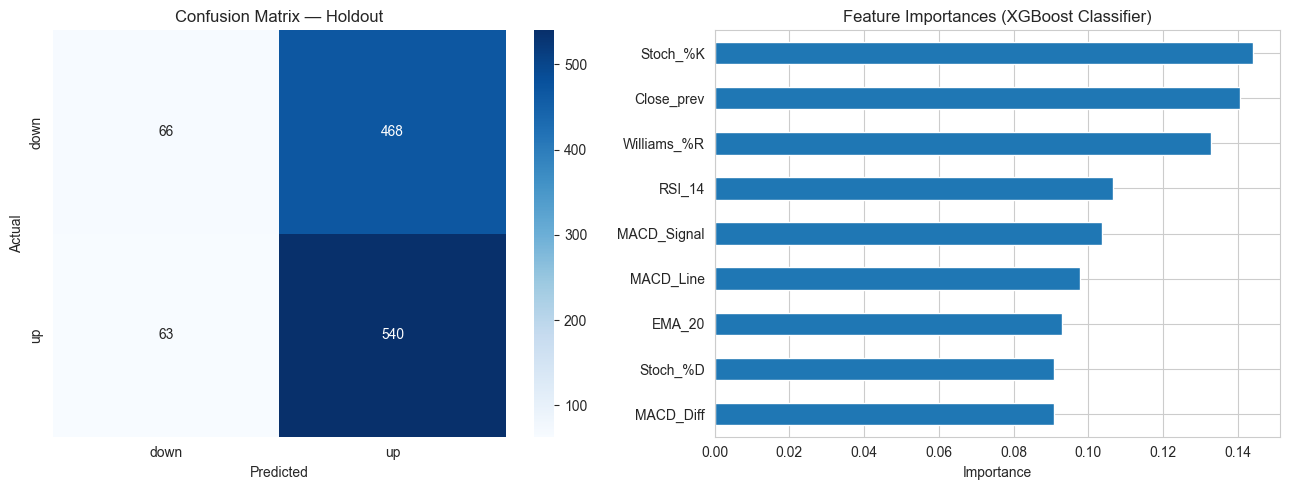

In [6]:
# ---------------------------------------------------------------
# 6. Classification — confusion matrix + feature importance
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(yc_hold, yc_pred_hold)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["down","up"], yticklabels=["down","up"], ax=axes[0])
axes[0].set_title("Confusion Matrix — Holdout")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fi = pd.Series(best_cls.feature_importances_, index=FEATURES).sort_values()
fi.plot(kind="barh", ax=axes[1])
axes[1].set_title("Feature Importances (XGBoost Classifier)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("plot7_classification_results.png", dpi=150)
plt.show()

In [7]:
# ---------------------------------------------------------------
# 7. Final summary — copy-paste ready
# ---------------------------------------------------------------
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print()
print("DATA")
print(f"  Ticker:              AAPL")
print(f"  Rows (after dropna): {len(model_df)}")
print(f"  Features:            {len(FEATURES)} technical indicators")
print(f"  Holdout period:      {dates_hold[0].date()} – {dates_hold[-1].date()}")
print()
print("REGRESSION (predict next-day % change)")
print(f"  Model:               XGBoost (best params tuned with TimeSeriesSplit CV)")
print(f"  Train R²:            {r2_train:.4f}")
print(f"  Holdout R²:          {r2_hold:.4f}")
print(f"  Holdout RMSE:        {rmse_hold:.4f}%")
print(f"  Dummy baseline R²:   {dummy_r2:.4f}")
print()
print("CLASSIFICATION (predict up/down direction)")
print(f"  Model:               XGBoost (best params tuned with TimeSeriesSplit CV)")
print(f"  Train accuracy:      {acc_train:.3f}")
print(f"  Holdout accuracy:    {acc_hold:.3f}")
print(f"  Dummy baseline:      {dummy_acc:.3f}  (majority class)")
print()
print("CONCLUSION")
print("  Both models perform at or below the trivial baseline on unseen data.")
print("  Daily returns are statistically consistent with white noise (EMH, weak form).")
print("  Technical indicators derived from past prices contain no exploitable signal")
print("  for next-day returns at the daily frequency.")
print("=" * 60)

FINAL SUMMARY

DATA
  Ticker:              AAPL
  Rows (after dropna): 11365
  Features:            9 technical indicators
  Holdout period:      2021-08-24 – 2026-03-05

REGRESSION (predict next-day % change)
  Model:               XGBoost (best params tuned with TimeSeriesSplit CV)
  Train R²:            0.0125
  Holdout R²:          0.0063
  Holdout RMSE:        1.7627%
  Dummy baseline R²:   -0.0007

CLASSIFICATION (predict up/down direction)
  Model:               XGBoost (best params tuned with TimeSeriesSplit CV)
  Train accuracy:      0.538
  Holdout accuracy:    0.533
  Dummy baseline:      0.530  (majority class)

CONCLUSION
  Both models perform at or below the trivial baseline on unseen data.
  Daily returns are statistically consistent with white noise (EMH, weak form).
  Technical indicators derived from past prices contain no exploitable signal
  for next-day returns at the daily frequency.
